In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    "User_ID":[1,2,3,4,5,6,7,8,9,10,
               11,12,13,14,15,16,17,18,19,20],

    "Page_Views":[2,3,10,8,12,1,15,9,4,2,
                  14,11,6,5,13,3,7,10,12,4],

    "Session_Duration_Min":[1,2,12,10,15,0.5,18,11,4,1,
                            16,14,6,5,17,2,8,13,15,3],

    "Bounce":[1,1,0,0,0,1,0,0,1,1,
              0,0,0,1,0,1,0,0,0,1],

    "Pages_Visited":[
        "Home",
        "Home",
        "Home→Products→Cart",
        "Home→Products",
        "Home→Products→Cart→Checkout",
        "Home",
        "Home→Products→Cart→Checkout",
        "Home→Products→Cart",
        "Home→Blog",
        "Home",
        "Home→Products→Checkout",
        "Home→Products→Cart",
        "Home→Blog→Products",
        "Home→Blog",
        "Home→Products→Cart→Checkout",
        "Home",
        "Home→Products",
        "Home→Products→Cart",
        "Home→Products→Cart→Checkout",
        "Home→Blog"
    ]
}

df = pd.DataFrame(data)

df.head()

,User_ID,Page_Views,Session_Duration_Min,Bounce,Pages_Visited
0,1,2,1.0,1,Home
1,2,3,2.0,1,Home
2,3,10,12.0,0,Home→Products→Cart
3,4,8,10.0,0,Home→Products
4,5,12,15.0,0,Home→Products→Cart→Checkout


In [3]:
print(df.shape)

df.info()

df.describe()

(20, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               20 non-null     int64  
 1   Page_Views            20 non-null     int64  
 2   Session_Duration_Min  20 non-null     float64
 3   Bounce                20 non-null     int64  
 4   Pages_Visited         20 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 932.0+ bytes


,User_ID,Page_Views,Session_Duration_Min,Bounce
count,20.00000,20.000000,20.000000,20.000000
mean,10.50000,7.550000,8.675000,0.400000
std,5.91608,4.430457,6.087682,0.502625
min,1.00000,1.000000,0.500000,0.000000
25%,5.75000,3.750000,2.750000,0.000000
50%,10.50000,7.500000,9.000000,0.000000
75%,15.25000,11.250000,14.250000,1.000000
max,20.00000,15.000000,18.000000,1.000000


In [4]:
print("Total Users:", len(df))

print("Total Page Views:", df["Page_Views"].sum())

print("Average Session Duration:",
      round(df["Session_Duration_Min"].mean(),2),"minutes")

Total Users: 20
Total Page Views: 151
Average Session Duration: 8.68 minutes


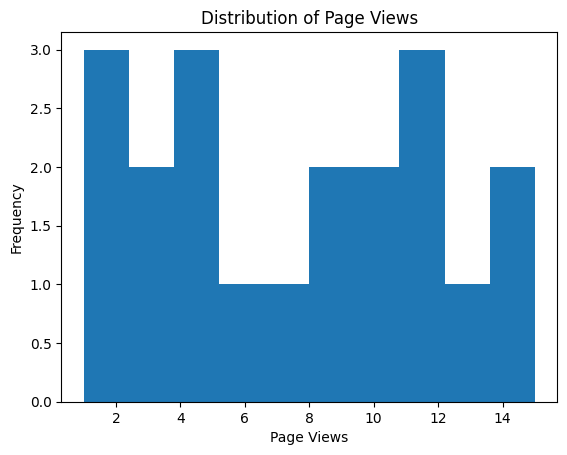

In [5]:
df["Page_Views"].plot(kind="hist")

plt.title("Distribution of Page Views")
plt.xlabel("Page Views")
plt.show()

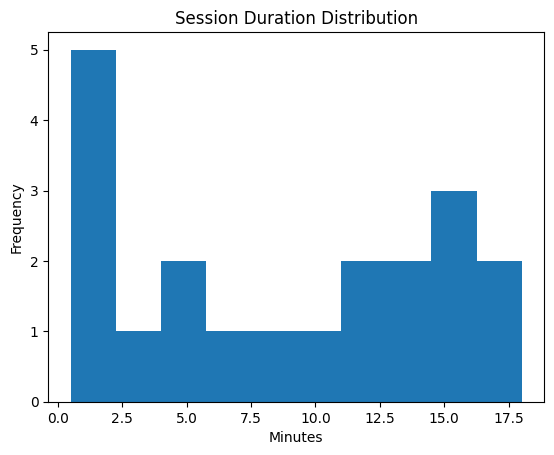

In [6]:
df["Session_Duration_Min"].plot(kind="hist")

plt.title("Session Duration Distribution")
plt.xlabel("Minutes")
plt.show()

In [7]:
bounce_rate = (
    df["Bounce"].sum()/len(df)
)*100

print("Bounce Rate:", round(bounce_rate,2),"%")

Bounce Rate: 40.0 %


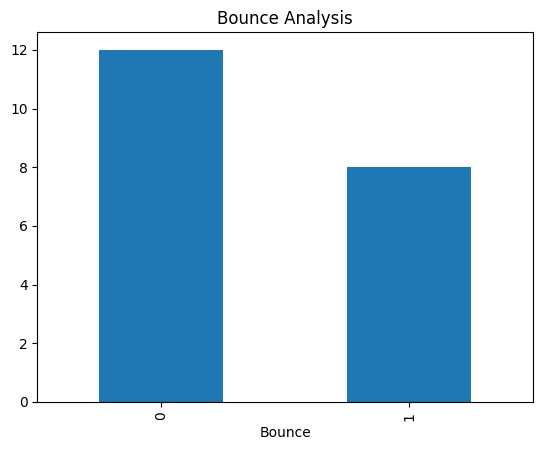

In [8]:
df["Bounce"].value_counts().plot(kind="bar")

plt.title("Bounce Analysis")
plt.show()

In [9]:
journey_counts = df["Pages_Visited"].value_counts()

print(journey_counts)

Pages_Visited
Home                           5
Home→Products→Cart             4
Home→Products→Cart→Checkout    4
Home→Blog                      3
Home→Products                  2
Home→Products→Checkout         1
Home→Blog→Products             1
Name: count, dtype: int64


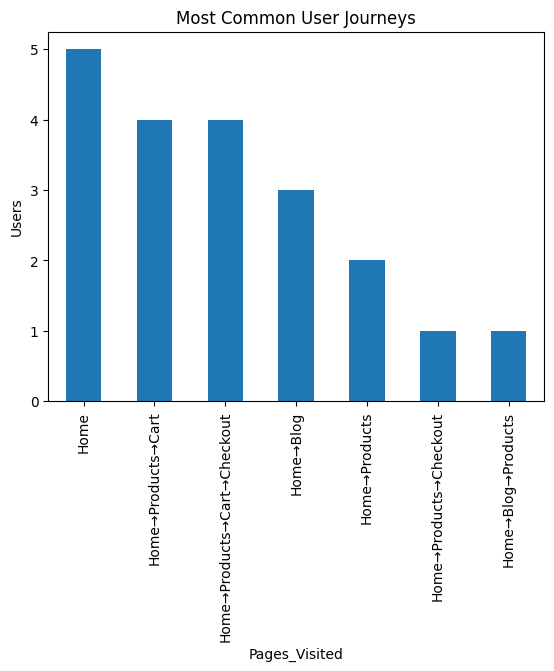

In [10]:
journey_counts.plot(kind="bar")

plt.title("Most Common User Journeys")

plt.ylabel("Users")

plt.show()

In [11]:
dropoffs = df[
    df["Pages_Visited"]=="Home"
]

print("Users Dropping at Homepage:")
print(len(dropoffs))

Users Dropping at Homepage:
5


In [12]:
df["Engagement"] = np.where(
    df["Session_Duration_Min"] > 10,
    "High",
    "Low"
)

df["Engagement"].value_counts()

,count
Engagement,
Low,11
High,9


In [13]:
df["Engagement"] = np.where(
    df["Session_Duration_Min"] > 10,
    "High",
    "Low"
)

df["Engagement"].value_counts()

,count
Engagement,
Low,11
High,9


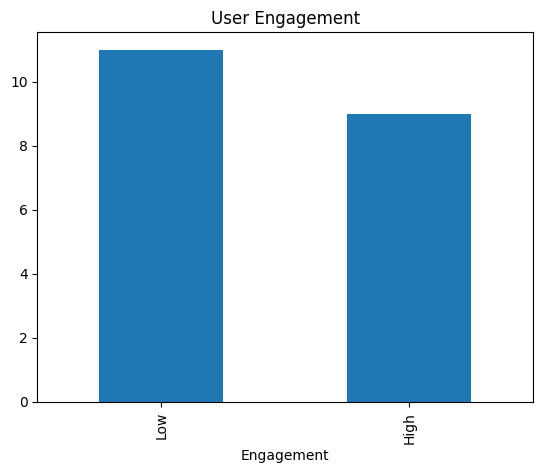

In [14]:
df["Engagement"].value_counts().plot(kind="bar")

plt.title("User Engagement")

plt.show()

In [16]:
df.to_csv(
    "web_traffic_analysis.csv",
    index=False
)

print("Analysis Completed Successfully")

Analysis Completed Successfully
